In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

notebook_dir = Path.cwd()
repo_dir = notebook_dir if (notebook_dir / 'yolov8n.pt').exists() else notebook_dir / 'PD-YOLO'
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

print(f'Using repository: {repo_dir.resolve()}')

Using repository: C:\Users\krish\OneDrive\Desktop\Study Material\SEM 5\CV PROJEC T\PD-YOLO


# PD-YOLO Pothole Detection Demo

This notebook loads the trained PD-YOLO pothole detector, runs inference on a sample image from the VOC2007 test set, displays the annotated result, and summarizes the detected potholes in a table.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO

# The trained checkpoint is trusted and was created before PyTorch 2.6.
def load_trusted_checkpoint(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return torch.serialization.load(*args, **kwargs)

torch.load = load_trusted_checkpoint

model_path = repo_dir / 'runs' / 'train' / 'exp8' / 'weights' / 'best.pt'
image_dir = repo_dir / 'dataset' / 'VOC2007' / 'test' / 'images'
image_paths = sorted(image_dir.glob('*.jpg'))[:16]
output_dir = repo_dir / 'runs' / 'model_demo'
output_dir.mkdir(parents=True, exist_ok=True)

if not model_path.exists():
    raise FileNotFoundError(f'Pothole model not found: {model_path}')
if len(image_paths) < 16:
    raise FileNotFoundError(f'Expected 16 VOC2007 test images in: {image_dir}')

image_path = image_paths[0]
print(f'Model: {model_path}')
print(f'Batch size: {len(image_paths)}')
print(f'First VOC2007 sample image: {image_path.name}')

Model: c:\Users\krish\OneDrive\Desktop\Study Material\SEM 5\CV PROJEC T\PD-YOLO\runs\train\exp8\weights\best.pt
Batch size: 16
First VOC2007 sample image: image_0002.jpg


In [3]:
model = YOLO(str(model_path))
model.info()

YOLOv8 summary: 225 layers, 3011238 parameters, 0 gradients, 8.2 GFLOPs


(225, 3011238, 0, 8.1952256)

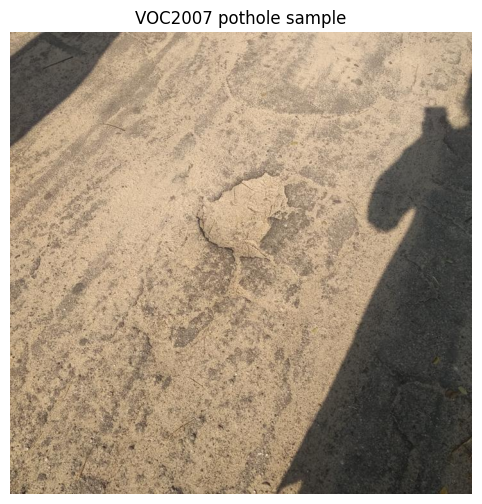

In [4]:
image = Image.open(image_path).convert('RGB')
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('off')
plt.title('VOC2007 pothole sample')
plt.show()

In [5]:
batch_tensor = torch.stack([
    torch.from_numpy(np.array(Image.open(path).convert('RGB').resize((640, 640)), copy=True)).permute(2, 0, 1)
    for path in image_paths
]).float() / 255.0

results = model.predict(source=batch_tensor, imgsz=640, conf=0.25, verbose=False)
print(f'Images in batch: {batch_tensor.shape[0]}')
print(f'Results returned: {len(results)}')
assert len(results) == 16, f'Expected 16 results, got {len(results)}'

Images in batch: 16
Results returned: 16


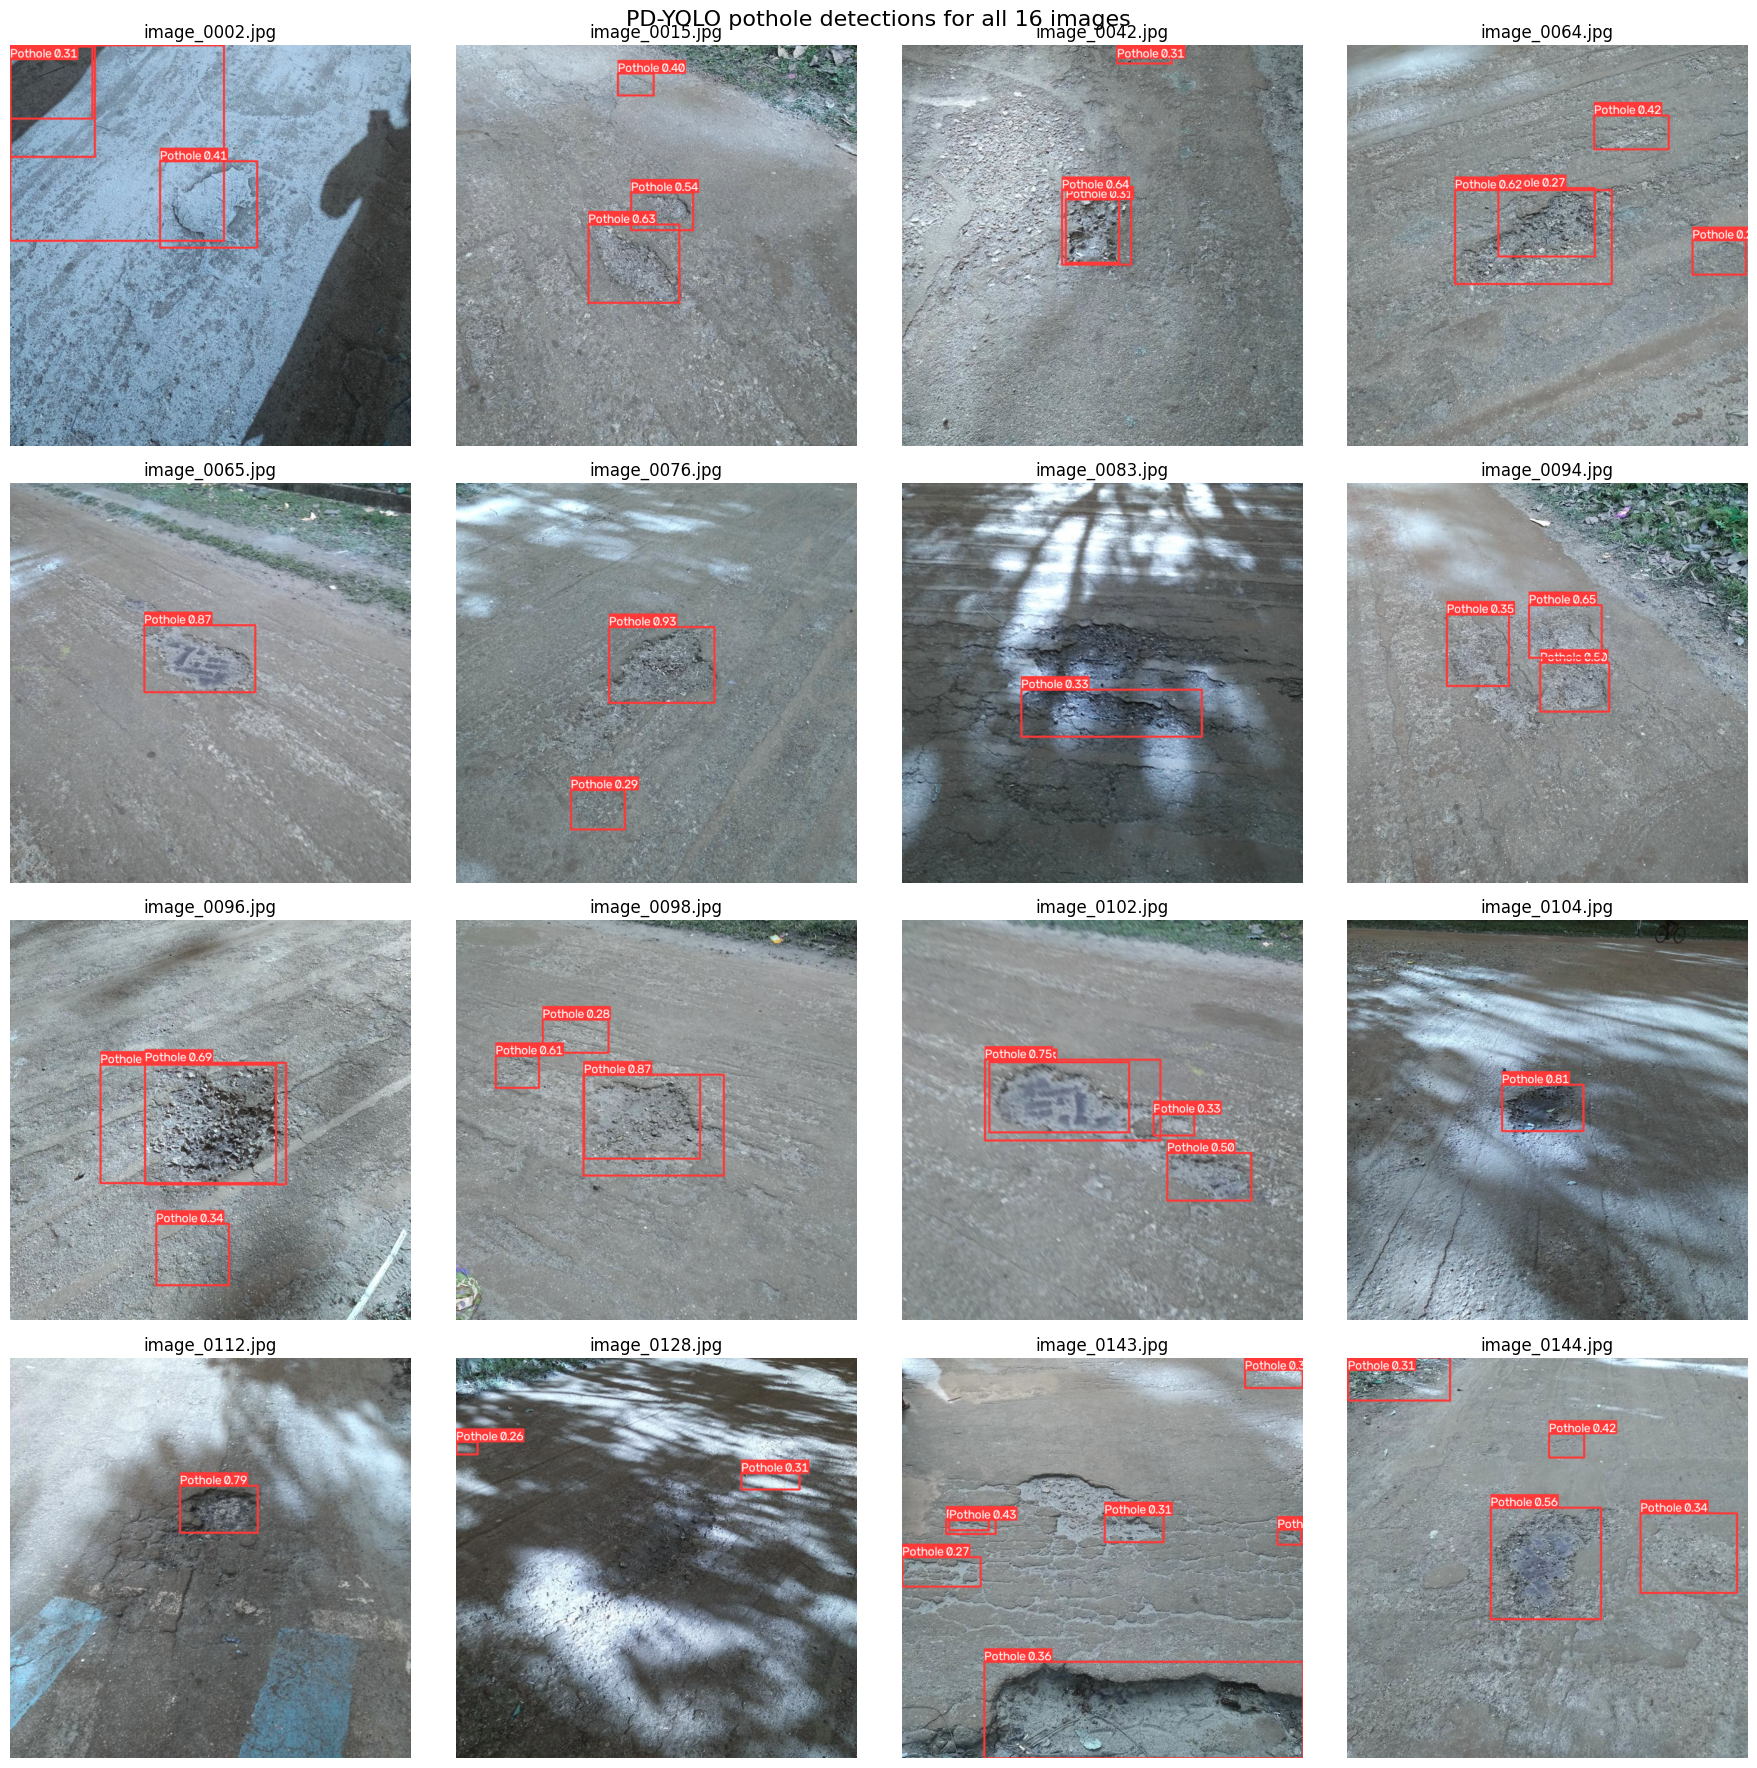

Saved 16 annotated images to: C:\Users\krish\OneDrive\Desktop\Study Material\SEM 5\CV PROJEC T\PD-YOLO\runs\model_demo\batch_predictions


In [6]:
batch_output_dir = output_dir / 'batch_predictions'
batch_output_dir.mkdir(parents=True, exist_ok=True)

annotated_images = []
for index, (image_path, result) in enumerate(zip(image_paths, results), start=1):
    annotated_image = result.plot()[:, :, ::-1]
    annotated_images.append(annotated_image)
    prediction_path = batch_output_dir / f'{image_path.stem}_prediction.jpg'
    Image.fromarray(annotated_image).save(prediction_path)

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
for axis, image_path, annotated_image in zip(axes.flat, image_paths, annotated_images):
    axis.imshow(annotated_image)
    axis.set_title(image_path.name)
    axis.axis('off')

fig.suptitle('PD-YOLO pothole detections for all 16 images', fontsize=16)
fig.tight_layout()
plt.show()
print(f'Saved {len(annotated_images)} annotated images to: {batch_output_dir.resolve()}')

In [7]:
detection_rows = []
for image_path, result in zip(image_paths, results):
    boxes = result.boxes
    if len(boxes):
        xyxy = boxes.xyxy.cpu().numpy()
        confidence = boxes.conf.cpu().numpy()
        class_ids = boxes.cls.cpu().numpy().astype(int)
        detection_rows.extend({
            'image': image_path.name,
            'class': result.names[class_id],
            'confidence': round(float(score), 3),
            'x1': round(float(box[0]), 1),
            'y1': round(float(box[1]), 1),
            'x2': round(float(box[2]), 1),
            'y2': round(float(box[3]), 1),
        } for box, score, class_id in zip(xyxy, confidence, class_ids))

detections = pd.DataFrame(
    detection_rows,
    columns=['image', 'class', 'confidence', 'x1', 'y1', 'x2', 'y2'],
)
detections

,image,class,confidence,x1,y1,x2,y2
0,image_0002.jpg,Pothole,0.414,239.2,185.5,394.3,323.1
1,image_0002.jpg,Pothole,0.313,0.0,0.0,135.4,178.9
2,image_0002.jpg,Pothole,0.257,0.0,0.0,341.2,312.9
3,image_0002.jpg,Pothole,0.250,0.8,2.3,131.8,117.1
4,image_0015.jpg,Pothole,0.627,211.0,286.1,356.6,411.5
5,image_0015.jpg,Pothole,0.543,279.6,235.1,378.5,296.0
6,image_0015.jpg,Pothole,0.401,258.6,45.3,315.9,80.5
7,image_0042.jpg,Pothole,0.635,255.5,231.9,365.6,350.2
8,image_0042.jpg,Pothole,0.309,343.5,0.0,430.6,29.6
9,image_0042.jpg,Pothole,0.306,261.5,247.0,346.4,347.2
